# RFNE Error Across Interpolation Steps

This notebook parses evaluation metric text files from `./assets/picked` and plots `avg_rfne_steps` for all picked models across NSKT, Shanghai, and SST.

- NSKT is filtered to `Re=36000` only.
- If a metrics file contains multiple appended evaluation blocks, the latest block is used.
- The output figure is one row with three panels, one panel per dataset.

In [1]:
from pathlib import Path
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd


ROOT = Path.cwd()
if not (ROOT / "assets").exists() and (ROOT.parent / "assets").exists():
    ROOT = ROOT.parent

ASSET_DIR = ROOT / "assets" / "picked"
OUTPUT_DIR = ROOT / "analysis"
OUTPUT_DIR.mkdir(exist_ok=True)

NSKT_RE = "36000"
METRIC_KEY = "avg_rfne_steps"

print(f"Root: {ROOT}")
print(f"Assets: {ASSET_DIR}")

Root: /pscratch/sd/p/puren93/puren/Interp-DM
Assets: /pscratch/sd/p/puren93/puren/Interp-DM/assets/picked


In [2]:
def extract_latest_metric_array(text, key=METRIC_KEY):
    """Return the latest array for `key` from an appended metrics text file."""
    pattern = re.compile(rf"{re.escape(key)}:\s*\[([^\]]+)\]", re.MULTILINE | re.DOTALL)
    matches = pattern.findall(text)
    if not matches:
        return None
    raw = matches[-1].replace("\n", " ")
    values = np.fromstring(raw, sep=" ")
    return values if values.size else None


def dataset_from_path(path):
    name = path.name
    if "Data_nskt" in name and f"eval_re{NSKT_RE}_" in name:
        return "NSKT"
    if "Data_shanghai" in name or name.startswith("eval_shanghai_"):
        return "Shanghai"
    if "Data_sst" in name or "Data_sea_temp" in name or name.startswith("eval_sst_"):
        return "SST"
    return None


def model_label_from_filename(path):
    stem = path.stem
    stem = re.sub(r"^eval_re\d+_", "", stem)
    stem = re.sub(r"^eval_shanghai_", "", stem)
    stem = re.sub(r"^eval_sst_", "", stem)
    stem = re.sub(r"_RE\d+$", "", stem)

    if stem.startswith("EDEN_"):
        return "EDEN"
    if "Model_SuperSloMo" in stem:
        return "SuperSloMo"
    if "Model_ft_UNet" in stem or "Model_UNet" in stem:
        return "UNet-ft" if "Model_ft_UNet" in stem else "UNet"

    flex_match = re.search(r"Model_(ft_)?(FLEX\d*|FLEX_noRe|FLEXResidual|FLEX)(?:_([^_]+))?_mlp(\d+)", stem)
    if flex_match:
        ft, family, size, mlp = flex_match.groups()
        label = family
        if ft:
            label += "-ft"
        if size:
            label += f" {size}"
        label += f" mlp{mlp}"
        lr_match = re.search(r"_lr([^_]+)_", stem)
        if lr_match:
            label += f" lr{lr_match.group(1)}"
        return label

    return stem


records = []
for path in sorted(ASSET_DIR.glob("*.txt")):
    dataset = dataset_from_path(path)
    if dataset is None:
        continue
    values = extract_latest_metric_array(path.read_text(encoding="utf-8"))
    if values is None:
        continue
    records.append({
        "dataset": dataset,
        "model": model_label_from_filename(path),
        "path": path,
        "rfne": values,
        "num_steps": len(values),
    })

print(f"Parsed {len(records)} metric files")
pd.DataFrame(
    [{"dataset": r["dataset"], "model": r["model"], "num_steps": r["num_steps"], "file": r["path"].name} for r in records]
).sort_values(["dataset", "model", "file"])

Parsed 8 metric files


,dataset,model,num_steps,file
4,SST,EDEN,10,eval_sst_EDEN_Data_sst_patch128_T10.txt
7,SST,FLEX-ft small mlp2 lr0.0001,10,eval_sst_Model_ft_FLEX_small_mlp2_Data_sea_tem...
5,SST,SuperSloMo,10,eval_sst_Model_SuperSloMo_Data_sea_temp_Optim_...
6,SST,UNet,10,eval_sst_Model_UNet_Data_sea_temp_Optim_adam_l...
0,Shanghai,EDEN,8,eval_shanghai_EDEN_Data_shanghai_patch128_T8.txt
1,Shanghai,FLEX small mlp2 lr0.0001,8,eval_shanghai_Model_FLEX_small_mlp2_Data_shang...
2,Shanghai,SuperSloMo,8,eval_shanghai_Model_SuperSloMo_Data_shanghai_O...
3,Shanghai,UNet,8,eval_shanghai_Model_UNet_Data_shanghai_Optim_a...


In [3]:
# Make duplicate labels unique while preserving readable model names.
label_counts = Counter((r["dataset"], r["model"]) for r in records)
seen = defaultdict(int)
for record in records:
    key = (record["dataset"], record["model"])
    if label_counts[key] > 1:
        seen[key] += 1
        record["plot_label"] = f"{record['model']} #{seen[key]}"
    else:
        record["plot_label"] = record["model"]

dataset_order = ["NSKT", "Shanghai", "SST"]
summary = pd.DataFrame(
    [
        {
            "dataset": r["dataset"],
            "label": r["plot_label"],
            "mean_rfne": float(np.mean(r["rfne"])),
            "num_steps": r["num_steps"],
            "file": r["path"].name,
        }
        for r in records
    ]
).sort_values(["dataset", "mean_rfne", "label"])
summary

,dataset,label,mean_rfne,num_steps,file
7,SST,FLEX-ft small mlp2 lr0.0001,0.018062,10,eval_sst_Model_ft_FLEX_small_mlp2_Data_sea_tem...
5,SST,SuperSloMo,0.022848,10,eval_sst_Model_SuperSloMo_Data_sea_temp_Optim_...
6,SST,UNet,0.022900,10,eval_sst_Model_UNet_Data_sea_temp_Optim_adam_l...
4,SST,EDEN,0.024898,10,eval_sst_EDEN_Data_sst_patch128_T10.txt
1,Shanghai,FLEX small mlp2 lr0.0001,0.326908,8,eval_shanghai_Model_FLEX_small_mlp2_Data_shang...
2,Shanghai,SuperSloMo,0.367747,8,eval_shanghai_Model_SuperSloMo_Data_shanghai_O...
3,Shanghai,UNet,0.485129,8,eval_shanghai_Model_UNet_Data_shanghai_Optim_a...
0,Shanghai,EDEN,0.585375,8,eval_shanghai_EDEN_Data_shanghai_patch128_T8.txt


In [4]:
# plt.rcParams.update({
#     "font.size": 11,
#     "axes.labelsize": 12,
#     "axes.titlesize": 13,
#     "legend.fontsize": 8,
#     "lines.linewidth": 2.0,
# })

# fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)

# for ax, dataset in zip(axes, dataset_order):
#     subset = [r for r in records if r["dataset"] == dataset]
#     subset = sorted(subset, key=lambda r: (float(np.mean(r["rfne"])), r["plot_label"]))

#     for record in subset:
#         steps = np.arange(1, record["num_steps"] + 1)
#         ax.plot(steps, record["rfne"], marker="o", markersize=3.5, label=record["plot_label"])

#     title = "NSKT (Re=36000)" if dataset == "NSKT" else dataset
#     ax.set_title(title)
#     ax.set_xlabel("Interpolation step")
#     ax.set_ylabel("RFNE")
#     ax.grid(True, alpha=0.25)
#     ax.set_xticks(np.arange(1, max([r["num_steps"] for r in subset], default=1) + 1))
#     ax.legend(loc="best", frameon=False)

# fig.suptitle("RFNE Error Across Interpolation Steps", y=1.03, fontsize=15)
# output_path = OUTPUT_DIR / "rfne_error_steps_all_datasets.png"
# fig.savefig(output_path, dpi=300, bbox_inches="tight")
# print(f"Saved figure to {output_path}")
# plt.show()


## Optional: Filter Models

If the figure is too crowded, set `KEEP_LABELS` below to a list of labels from the summary table and rerun the plotting cell with `filtered_records`.

In [4]:
KEEP_LABELS = []  # Example: ["EDEN", "SuperSloMo", "UNet-ft", "FLEX-ft small mlp2 lr0.0001"]

filtered_records = [r for r in records if not KEEP_LABELS or r["plot_label"] in KEEP_LABELS]
print(f"Kept {len(filtered_records)} / {len(records)} curves")

Kept 8 / 8 curves


In [5]:
nskt = {
    "UNet": [
        0.08678201, 0.10351695, 0.13400497, 0.1732818, 0.21359006, 0.26103,
        0.31032532, 0.372788, 0.4306879, 0.4763834, 0.50009084, 0.50334233,
        0.49255145, 0.47502822, 0.44795096, 0.41794166, 0.3752049, 0.32491302,
        0.27747074, 0.236507
    ], # 0.436507
    "Super SloMo": [
        0.06345925, 0.07247326, 0.09472109, 0.11487574, 0.13337685, 0.14981394,
        0.16334559, 0.17422862, 0.18227805, 0.18619967, 0.18659817, 0.18332951,
        0.17819767, 0.17310487, 0.168433, 0.16304922, 0.15684275, 0.15033433,
        0.14495388, 0.1471057
    ], 
    "EDEN": [
        0.10762456, 0.10805508, 0.10642237, 0.11215479, 0.11835976, 0.12634961,
        0.13073359, 0.13889593, 0.14623436, 0.15332313, 0.15548144, 0.14596523,
        0.13920747, 0.13028006, 0.12368236, 0.11626866, 0.11294746, 0.11108014,
        0.11077095, 0.11345973
    ],
    "Ours": [
        0.01086416, 0.01756179, 0.02485763, 0.03232484, 0.03740804, 0.0509124,
        0.04883808, 0.05203953, 0.05613035, 0.05522718, 0.0573272, 0.0592651,
        0.05067941, 0.05304889, 0.04254201, 0.03346165, 0.02635225, 0.02137119,
        0.01662585, 0.01017673
    ],
}

shanghai = {
    "UNet": [
        0.25341865, 0.39330453, 0.4939342, 0.57830983, 0.59979683, 0.561535,
        0.46546146, 0.33526944
    ], # 0.53526944
    "Super SloMo": [
        0.22092146, 0.33472607, 0.40280676, 0.44190007, 0.45907965, 0.44863194,
        0.39113936, 0.2427738
    ],
    "EDEN": [
        0.58464533, 0.58254106, 0.58550506, 0.58745616, 0.58661447, 0.58567583,
        0.58277208, 0.58778858
    ],
    "Ours": [
        0.21717438, 0.32454923, 0.37420064, 0.38782734, 0.39036396, 0.3804188,
        0.32293665, 0.21779236
    ],
}

sst = {
    "UNet": [
        0.01033774, 0.01818569, 0.02427262, 0.02905321, 0.0321947, 0.03165804,
        0.02798159, 0.02411572, 0.02055559, 0.01064729
    ],
    "Super SloMo": [
        0.01364987, 0.02197324, 0.02683247, 0.0292012, 0.02974576, 0.02881416,
        0.02658993, 0.02301303, 0.01793548, 0.01072464
    ],
    "EDEN": [
        0.02558023, 0.0249967, 0.02467457, 0.02483201, 0.02505331, 0.02510981,
        0.02489704, 0.02467574, 0.02467671, 0.02448206
    ],
    "Ours": [
        0.01027181, 0.0144413, 0.01796848, 0.02028144, 0.02156075, 0.02229583,
        0.02157452, 0.02229648, 0.01853128, 0.01139344
    ],
}


Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_all_datasets_manual.png
Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_all_datasets_manual.pdf


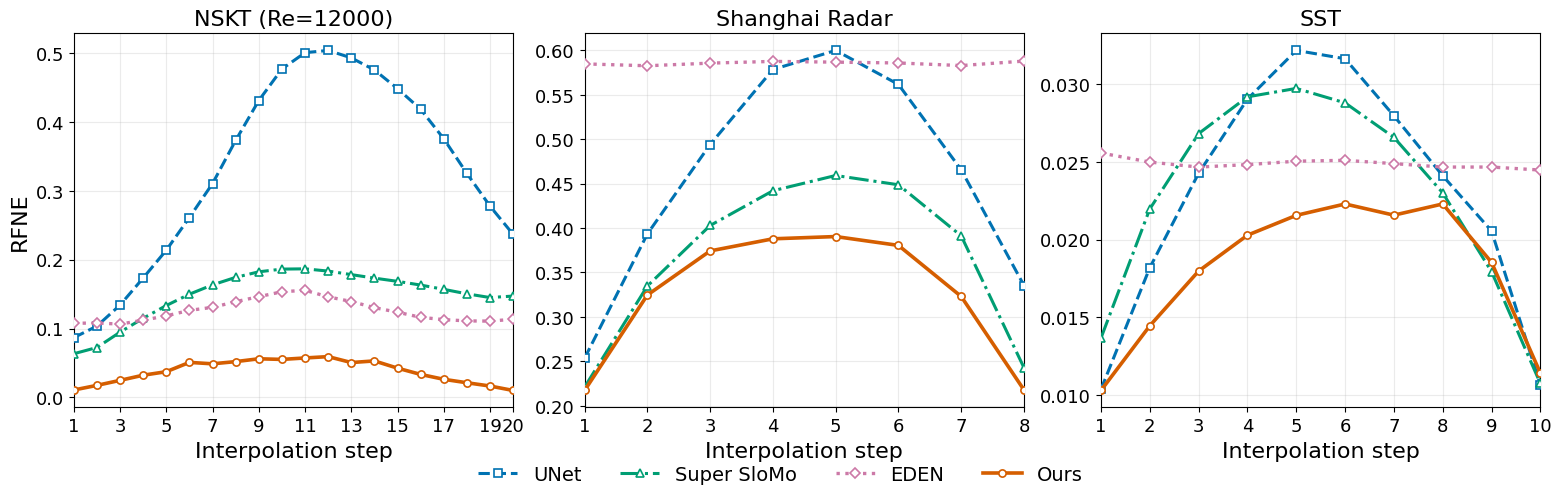

In [6]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path.cwd()
    if OUTPUT_DIR.name != "analysis":
        OUTPUT_DIR = OUTPUT_DIR / "analysis"
    OUTPUT_DIR.mkdir(exist_ok=True)

manual_datasets = {
    "NSKT (Re=12000)": nskt,
    "Shanghai Radar": shanghai,
    "SST": sst,
}

all_rfne_values = np.concatenate([
    np.asarray(values, dtype=float)
    for curves in manual_datasets.values()
    for values in curves.values()
])
rfne_y_limits = (
    10 ** np.floor(np.log10(all_rfne_values.min())),
    10 ** np.ceil(np.log10(all_rfne_values.max())),
)

RFNE_LINE_STYLES = {
    "Ours": {"color": "#D55E00", "marker": "o", "linestyle": "-", "linewidth": 2.6, "zorder": 4},
    "iFLEX": {"color": "#D55E00", "marker": "o", "linestyle": "-", "linewidth": 2.6, "zorder": 4}, #  "#0072B2"
    "UNet": {"color": "#0072B2", "marker": "s", "linestyle": "--", "linewidth": 2.2, "zorder": 3},
    "Super SloMo": {"color": "#009E73", "marker": "^", "linestyle": "-.", "linewidth": 2.2, "zorder": 3},
    "EDEN": {"color": "#CC79A7", "marker": "D", "linestyle": ":", "linewidth": 2.4, "zorder": 3},
    "iFLEX w/ Residual": {"color": "#56B4E9", "marker": "P", "linestyle": "--", "linewidth": 2.3, "zorder": 3},
    "iFLEX w/o Multi-resolution": {"color": "#E69F00", "marker": "v", "linestyle": "-.", "linewidth": 2.3, "zorder": 3},
    "Extrapolation": {"color": "#56B4E9", "marker": "P", "linestyle": "--", "linewidth": 2.3, "zorder": 3},
    "Interpolation": {"color": "#E69F00", "marker": "v", "linestyle": "-.", "linewidth": 2.3, "zorder": 3},
}

RFNE_MARKER_STYLE = {
    "markersize": 5.2,
    "markerfacecolor": "white",
    "markeredgewidth": 1.2,
}


def rfne_line_style(label):
    style = dict(RFNE_LINE_STYLES[label])
    style.update(RFNE_MARKER_STYLE)
    return style

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 16, #12,
    "axes.titlesize": 16, #13,
    "legend.fontsize": 14, # 12,
    "lines.linewidth": 2.0,
})

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), constrained_layout=True)

for axis_idx, (ax, (dataset_name, curves)) in enumerate(zip(axes, manual_datasets.items())):
    for method in ["UNet", "Super SloMo", "EDEN", "Ours"]:
        values = np.asarray(curves[method], dtype=float)
        steps = np.arange(1, len(values) + 1)
        ax.plot(
            steps,
            values,
            label=method,
            **rfne_line_style(method),
        )

    max_steps = max(len(v) for v in curves.values())
    ax.set_title(dataset_name)
    ax.set_xlabel("Interpolation step")
    if axis_idx == 0:
        ax.set_ylabel("RFNE")
    else:
        ax.set_ylabel("")
    #ax.set_yscale("log")
    #ax.set_ylim(*rfne_y_limits)
    #ax.yaxis.set_major_locator(mticker.LogLocator(base=10, subs=(1.0,), numticks=4))
    #ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    #ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1, numticks=12))
    #ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    #ax.yaxis.get_offset_text().set_visible(False)
    ax.set_xlim(1, max_steps)
    if dataset_name.startswith("NSKT"):
        nskt_ticks = list(np.arange(1, max_steps + 1, 2))
        if nskt_ticks[-1] != max_steps:
            nskt_ticks.append(max_steps)
        ax.set_xticks(nskt_ticks)
    else:
        ax.set_xticks(np.arange(1, max_steps + 1))
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.08))
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.08))
# fig.suptitle("RFNE Error Across Interpolation Steps", y=1.16, fontsize=15)

output_png = OUTPUT_DIR / "rfne_error_steps_all_datasets_manual.png"
output_pdf = OUTPUT_DIR / "rfne_error_steps_all_datasets_manual.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved figure to {output_png}")
print(f"Saved figure to {output_pdf}")
plt.show()


In [7]:
nskt_36k = {
    # "flex_residual": [
    #     0.01326873, 0.02299408, 0.03314035, 0.04166405, 0.04715541,
    #     0.05269307, 0.05827571, 0.06028776, 0.06186978, 0.0626973,
    #     0.06169138, 0.0623448, 0.06164854, 0.05882679, 0.05727784,
    #     0.05399257, 0.0565218, 0.04973754, 0.04000754, 0.03453352
    # ],

    # residual
    # "flex_residual": [
    #     0.01339094, 0.02252489, 0.03231947, 0.04090879, 0.04578891, 0.0517157,
    #     0.05695674, 0.05871839, 0.06008895, 0.06127364, 0.0598153, 0.06043576,
    #     0.05950369, 0.05678731, 0.05508078, 0.05184775, 0.05382023, 0.04735998,
    #     0.03745253, 0.0316175
    # ],


    # # residual and last state zero
    # "flex_residual": [
    #     0.02999341, 0.0572822 , 0.08392126, 0.11080344, 0.1359102 ,
    #     0.16083832, 0.18667658, 0.20994462, 0.23200853, 0.25720096,
    #     0.27503604, 0.29842755, 0.31915373, 0.3393912 , 0.35860288,
    #     0.3780585 , 0.39404392, 0.41132718, 0.42342293, 0.44377786
    # ],

    # # pure forecasting in an auto-regressive manner
    # "flex_residual": [0.02000481, 0.03868556, 0.05728757, 0.07593244, 0.094469  ,
    #    0.11285359, 0.13139312, 0.14976008, 0.16785413, 0.18581712,
    #    0.20370871, 0.22136904, 0.23885122, 0.25593394, 0.27282703,
    #    0.2895666 , 0.3060769 , 0.3224731 , 0.33837867, 0.35428149],

    "flex_residual": [
        0.0049349, 0.00957266, 0.0148396, 0.02100765, 0.02801077, 0.03580724,
        0.04434244, 0.05348629, 0.06310949, 0.07323036, 0.08374809, 0.09464748,
        0.10596876, 0.11764624, 0.12962449, 0.14190355, 0.15445285, 0.16733176,
        0.1805283, 0.19406988
    ],


    "flex": [
        0.01275988, 0.0211098, 0.02824505, 0.03443375, 0.03961837,
        0.04531553, 0.04789506, 0.05074674, 0.05259246, 0.05339825,
        0.05422056, 0.05374828, 0.05087243, 0.04910036, 0.04440152,
        0.03863119, 0.03314763, 0.02719647, 0.02119057, 0.01247676
    ]
}


Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_nskt_36k_flex_vs_residualzero.png
Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_nskt_36k_flex_vs_residualzero.pdf


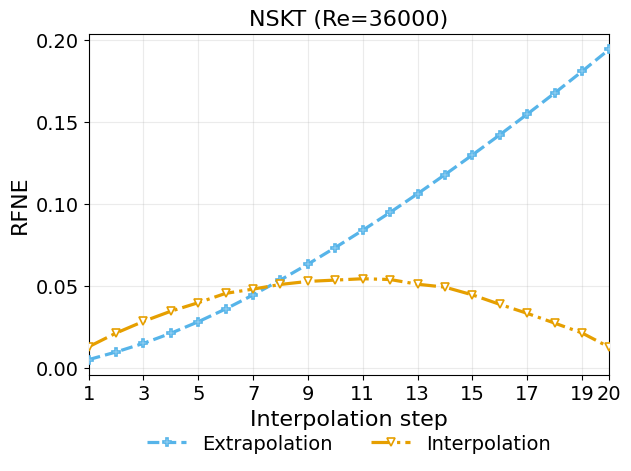

In [11]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path.cwd()
    if OUTPUT_DIR.name != "analysis":
        OUTPUT_DIR = OUTPUT_DIR / "analysis"
    OUTPUT_DIR.mkdir(exist_ok=True)

# nskt_36k_curves = {
#     "iFLEX w/ Residual": nskt_36k["flex_residual"],
#     "iFLEX": nskt_36k["flex"],
# }
nskt_36k_curves = {
    "Extrapolation": nskt_36k["flex_residual"],
    "Interpolation": nskt_36k["flex"],
}


plt.rcParams.update({
    "font.size": 14, # 13,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14, # 12,
    "lines.linewidth": 2.0,
})

fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.6), constrained_layout=True)

for method, values in nskt_36k_curves.items():
    values = np.asarray(values, dtype=float)
    steps = np.arange(1, len(values) + 1)
    ax.plot(
        steps,
        values,
        label=method,
        **rfne_line_style(method),
    )

max_steps = max(len(v) for v in nskt_36k_curves.values())
nskt_ticks = list(np.arange(1, max_steps + 1, 2))
if nskt_ticks[-1] != max_steps:
    nskt_ticks.append(max_steps)

ax.set_title("NSKT (Re=36000)")
ax.set_xlabel("Interpolation step")
ax.set_ylabel("RFNE")
ax.set_xlim(1, max_steps)
ax.set_xticks(nskt_ticks)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.28))

output_png = OUTPUT_DIR / "rfne_error_steps_nskt_36k_flex_vs_residualzero.png"
output_pdf = OUTPUT_DIR / "rfne_error_steps_nskt_36k_flex_vs_residualzero.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved figure to {output_png}")
print(f"Saved figure to {output_pdf}")
plt.show()

Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_nskt_36k_flex_vs_multireso.png
Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_nskt_36k_flex_vs_multireso.pdf


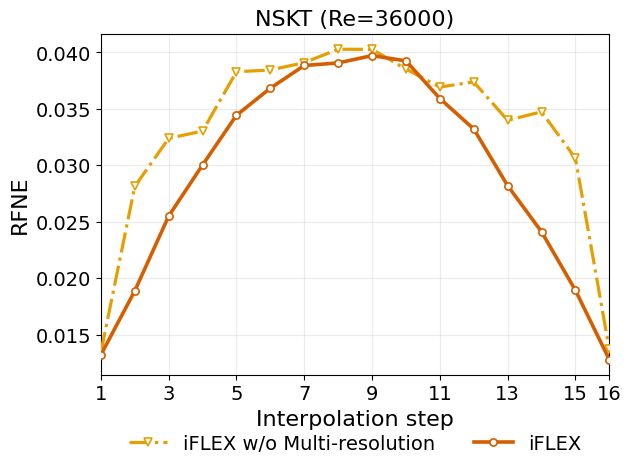

In [31]:
nskt_36k_multi_reso = {
    "flex_multi_reso": [0.01345547, 0.02813146, 0.0323878, 0.03303834, 0.03829258, 0.03844451,
 0.0391001, 0.04028427, 0.04027541, 0.03853035, 0.03693639, 0.03738949,
 0.03398778, 0.03474203, 0.03062507, 0.01371248],
    "flex": [0.01321393, 0.01888104, 0.02550392, 0.03003519, 0.03443891, 0.03683569,
 0.03884479, 0.03907255, 0.03971935, 0.03925536, 0.03591917, 0.03322267,
 0.02820186, 0.02411721, 0.01893092, 0.01278692]
}

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path.cwd()
    if OUTPUT_DIR.name != "analysis":
        OUTPUT_DIR = OUTPUT_DIR / "analysis"
    OUTPUT_DIR.mkdir(exist_ok=True)

nskt_36k_curves = {
    "iFLEX w/o Multi-resolution": nskt_36k_multi_reso["flex_multi_reso"],
    "iFLEX": nskt_36k_multi_reso["flex"],
}

plt.rcParams.update({
    "font.size": 14, #13,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14, # 12,
    "lines.linewidth": 2.0,
})

fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.6), constrained_layout=True)

for method, values in nskt_36k_curves.items():
    values = np.asarray(values, dtype=float)
    steps = np.arange(1, len(values) + 1)
    ax.plot(
        steps,
        values,
        label=method,
        **rfne_line_style(method),
    )

max_steps = max(len(v) for v in nskt_36k_curves.values())
nskt_ticks = list(np.arange(1, max_steps + 1, 2))
if nskt_ticks[-1] != max_steps:
    nskt_ticks.append(max_steps)

ax.set_title("NSKT (Re=36000)")
ax.set_xlabel("Interpolation step")
ax.set_ylabel("RFNE")
ax.set_xlim(1, max_steps)
ax.set_xticks(nskt_ticks)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.28))

output_png = OUTPUT_DIR / "rfne_error_steps_nskt_36k_flex_vs_multireso.png"
output_pdf = OUTPUT_DIR / "rfne_error_steps_nskt_36k_flex_vs_multireso.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved figure to {output_png}")
print(f"Saved figure to {output_pdf}")
plt.show()


Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_ablation_flex_summary.png
Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_ablation_flex_summary.pdf
Full Model: 3.86%
Model C: 3.96%
Model B: 4.53%
Model A: 8.59%


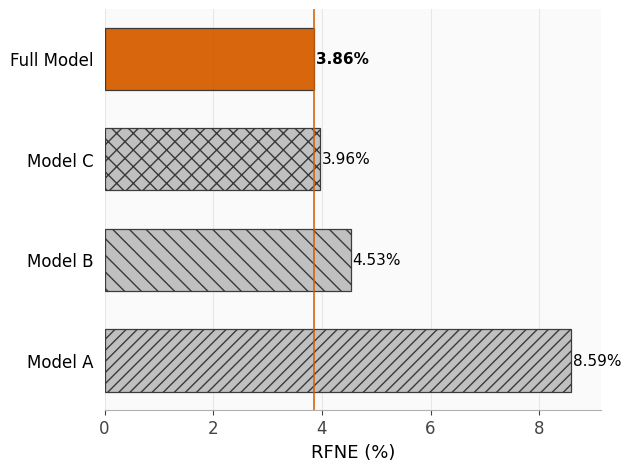

In [10]:
# Ablation summary: use a sorted bar chart for a small set of scalar RFNE values.
# This emphasizes the ranking and the RFNE increase relative to the full FLEX model.
from pathlib import Path

import matplotlib.pyplot as plt

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path.cwd()
    if OUTPUT_DIR.name != "analysis":
        OUTPUT_DIR = OUTPUT_DIR / "analysis"
    OUTPUT_DIR.mkdir(exist_ok=True)

ablation_rfne = sorted(
    [
        {"Model": "Model A", "RFNE (%)": 8.59}, # 4.79 / 26.6 (pure forecasting)
        {"Model": "Model B", "RFNE (%)": 4.53},
        {"Model": "Model C", "RFNE (%)": 3.96},
        {"Model": "Full Model", "RFNE (%)": 3.86},
    ],
    key=lambda row: row["RFNE (%)"],
    reverse=False,
)

full_rfne = next(row["RFNE (%)"] for row in ablation_rfne if row["Model"] == "Full Model")
ablation_hatches = {
    "Full Model": "",
    "Model A": "///",
    "Model B": "\\\\",
    "Model C": "xx",
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
})

fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.6), constrained_layout=True)
fig.patch.set_facecolor("white")
ax.set_facecolor("#fafafa")

models = [row["Model"] for row in ablation_rfne]
rfne_values = [row["RFNE (%)"] for row in ablation_rfne]
ct_flex_color = RFNE_LINE_STYLES["iFLEX"]["color"]
colors = [ct_flex_color if model == "Full Model" else "#bdbdbd" for model in models]
bars = ax.barh(
    models,
    rfne_values,
    height=0.62,
    color=colors,
    edgecolor="#333333",
    linewidth=0.9,
    alpha=0.95,
)
for bar, model in zip(bars, models):
    bar.set_hatch(ablation_hatches[model])

ax.invert_yaxis()
ax.axvline(full_rfne, color=ct_flex_color, linestyle=RFNE_LINE_STYLES["iFLEX"]["linestyle"], linewidth=1.4, alpha=0.8)

for bar, row in zip(bars, ablation_rfne):
    value = row["RFNE (%)"]
    ax.text(
        value + 0.035,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="semibold" if row["Model"] == "Full Model" else "normal",
    )

# ax.set_title("FLEX Ablation Study")
ax.set_xlabel("RFNE (%)")
ax.set_xlim(0, max(rfne_values) + 0.55)
ax.grid(axis="x", color="#d0d0d0", linewidth=0.8, alpha=0.45)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#b0b0b0")
ax.tick_params(axis="y", length=0, pad=8)
ax.tick_params(axis="x", colors="#444444")

output_png = OUTPUT_DIR / "rfne_ablation_flex_summary.png"
output_pdf = OUTPUT_DIR / "rfne_ablation_flex_summary.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved figure to {output_png}")
print(f"Saved figure to {output_pdf}")
for row in ablation_rfne:
    print(f"{row['Model']}: {row['RFNE (%)']:.2f}%")
plt.show()


In [35]:
nskt_36k_12steps = {
    "super slomo": [
        0.09443641, 0.1328355, 0.1854569, 0.22964843, 0.2692929, 0.30597425,
        0.3375359, 0.36474186, 0.3896806, 0.41421402, 0.43860584, 0.4617465
    ],
    "EDEN": [
        0.13148975, 0.13657753, 0.14350802, 0.15040247, 0.16017061, 0.16831667,
        0.17200599, 0.161465, 0.15129812, 0.14274554, 0.13774274, 0.13695682
    ],
    "flex": [
        0.01111427, 0.01992134, 0.02449984, 0.02835208, 0.0304163, 0.03094392,
        0.03077635, 0.028504, 0.02679069, 0.02182381, 0.01734672, 0.01108004
    ]
}

nskt_36k_16steps = {
    "super slomo": [
        0.1047122, 0.12811701, 0.16852953, 0.20244662, 0.232558, 0.25935334,
        0.28124171, 0.2989502, 0.3135409, 0.32597172, 0.3361856, 0.34335452,
        0.3526925, 0.36697254, 0.3852259, 0.40540382
    ],
    "EDEN": [
        0.16121721, 0.16861656, 0.17635913, 0.18862757, 0.20072737, 0.21039259,
        0.2191356, 0.22736848, 0.2333873, 0.21994576, 0.20964651, 0.19860754,
        0.18876843, 0.1811428, 0.17398145, 0.17529444
    ],
    "flex": [
        0.01321393, 0.01888104, 0.02550392, 0.03003519, 0.03443891, 0.03683569,
        0.03884479, 0.03907255, 0.03971935, 0.03925536, 0.03591917, 0.03322267,
        0.02820186, 0.02411721, 0.01893092, 0.01278692
    ]
}

nskt_36k_24steps = {
    "super slomo": [
        0.13007103, 0.14370069, 0.18130633, 0.21743515, 0.24926305, 0.27642488,
        0.29948503, 0.31926677, 0.33531886, 0.3458646, 0.35256186, 0.35696247,
        0.35797152, 0.35627878, 0.35347596, 0.35047764, 0.346947, 0.34304988,
        0.34010872, 0.3349705, 0.31716275, 0.28245342, 0.24111609, 0.2137453
    ],
    "EDEN": [
        0.24046999, 0.24570158, 0.25795848, 0.26395388, 0.27407367, 0.28683192,
        0.30134023, 0.31116638, 0.32357161, 0.32964664, 0.33888694, 0.34762682,
        0.35378763, 0.34317751, 0.33287506, 0.32338005, 0.31418624, 0.30283944,
        0.29011811, 0.2794924, 0.26822445, 0.26413777, 0.25454974, 0.26318124
    ],
    "flex": [
        0.02452557, 0.02636954, 0.03312614, 0.04154691, 0.04867968, 0.05513193,
        0.0619631, 0.06632447, 0.06975109, 0.07290996, 0.07468085, 0.07595725,
        0.07695436, 0.07667229, 0.07559048, 0.07209089, 0.06976958, 0.06284447,
        0.0556196, 0.04832288, 0.04099799, 0.03308255, 0.02573338, 0.0231779 
    ]
}


## Generalization Across Interpolation Step Counts

Compare NSKT Re=36000 RFNE curves when evaluating at 12, 16, and 24 interpolation steps.


Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_nskt_36k_generalization_interpolation_steps.png
Saved figure to /pscratch/sd/p/puren93/puren/Interp-DM/analysis/rfne_error_steps_nskt_36k_generalization_interpolation_steps.pdf


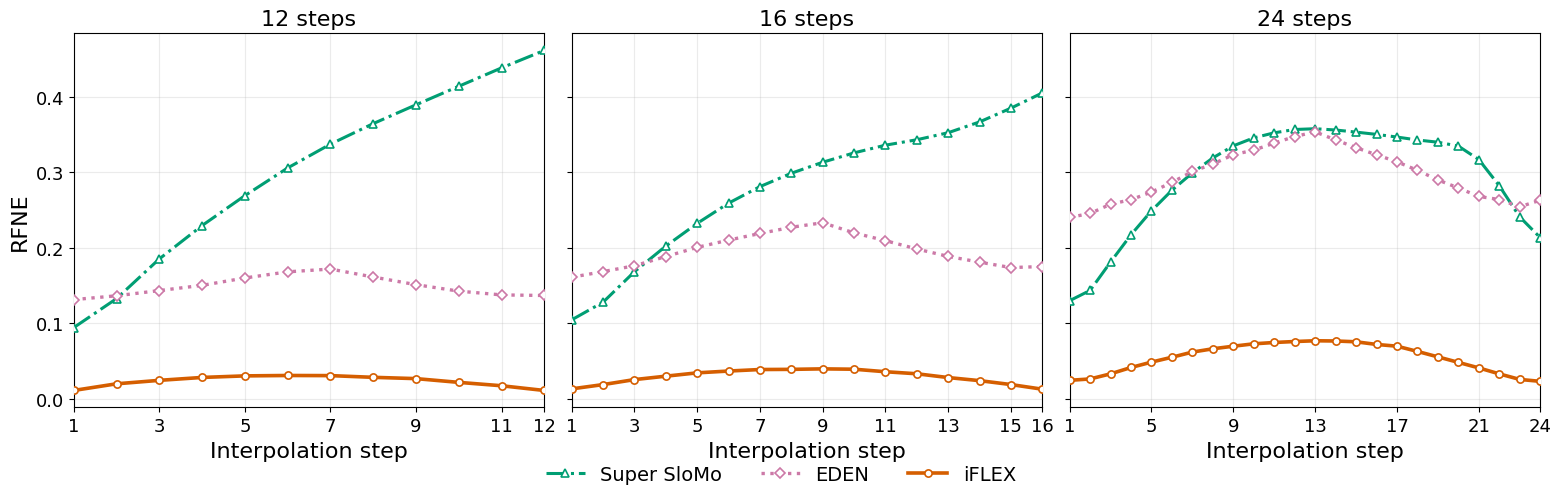

In [36]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path.cwd()
    if OUTPUT_DIR.name != "analysis":
        OUTPUT_DIR = OUTPUT_DIR / "analysis"
    OUTPUT_DIR.mkdir(exist_ok=True)

step_generalization = {
    "12 steps": nskt_36k_12steps,
    "16 steps": nskt_36k_16steps,
    "24 steps": nskt_36k_24steps,
}

method_labels = {
    "flex": "iFLEX",
    "EDEN": "EDEN",
    "super slomo": "Super SloMo",
}

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 14, # 12,
    "lines.linewidth": 2.0,
})

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), constrained_layout=True, sharey=True)

for ax, (step_label, curves) in zip(axes, step_generalization.items()):
    for method_key in ["super slomo", "EDEN", "flex"]:
        values = np.asarray(curves[method_key], dtype=float)
        steps = np.arange(1, len(values) + 1)
        label = method_labels[method_key]
        ax.plot(
            steps,
            values,
            label=label,
            **rfne_line_style(label),
        )

    max_steps = max(len(v) for v in curves.values())
    tick_step = 2 if max_steps <= 16 else 4
    xticks = list(np.arange(1, max_steps + 1, tick_step))
    if xticks[-1] != max_steps:
        xticks.append(max_steps)

    ax.set_title(step_label)
    ax.set_xlabel("Interpolation step")
    ax.set_xlim(1, max_steps)
    ax.set_xticks(xticks)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("RFNE")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.08))

output_png = OUTPUT_DIR / "rfne_error_steps_nskt_36k_generalization_interpolation_steps.png"
output_pdf = OUTPUT_DIR / "rfne_error_steps_nskt_36k_generalization_interpolation_steps.pdf"
fig.savefig(output_png, dpi=300, bbox_inches="tight")
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved figure to {output_png}")
print(f"Saved figure to {output_pdf}")
plt.show()